## Activation Functions

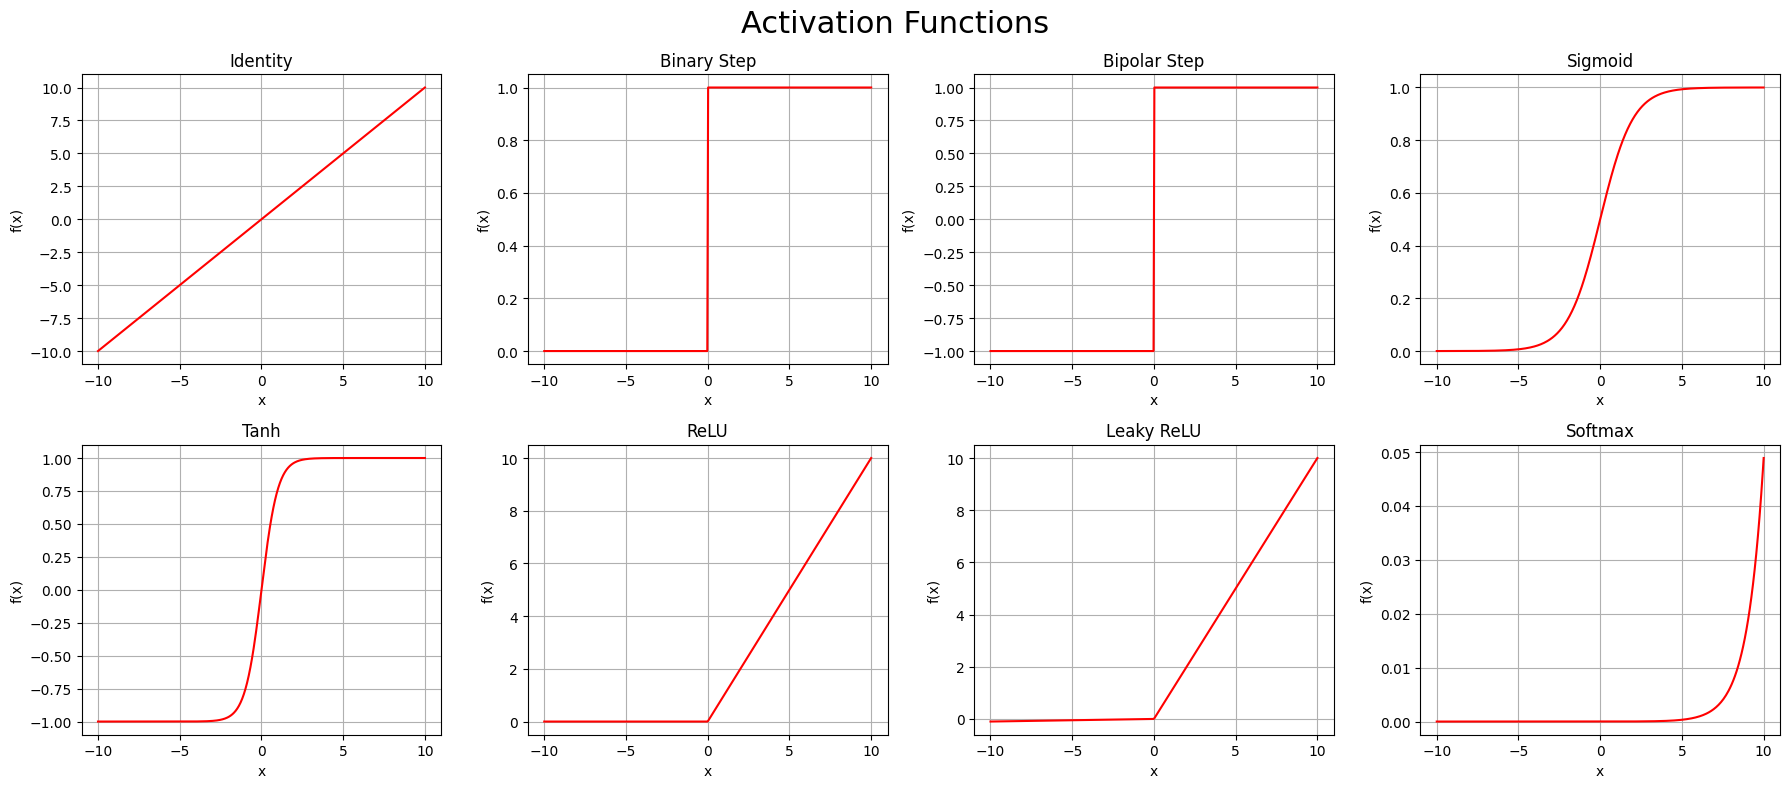

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def identity(x):
    return x

def binary_step(x):
    return np.where(x >= 0, 1, 0)

def bipolar_step(x):
    return np.where(x >= 0, 1, -1)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh_function(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def softmax(x):
    exp_x = np.exp(x - np.max(x))   # for numerical stability
    return exp_x / np.sum(exp_x)

# Generate random dataset using numpy
x = np.linspace(-10, 10, 400)

# Dictionary of functions
functions = {
    "Identity": identity(x),
    "Binary Step": binary_step(x),
    "Bipolar Step": bipolar_step(x),
    "Sigmoid": sigmoid(x),
    "Tanh": tanh_function(x),
    "ReLU": relu(x),
    "Leaky ReLU": leaky_relu(x),
    "Softmax": softmax(x)
}

# Create subplots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

fig.suptitle("Activation Functions", fontsize=22)

# Plot each function
for ax, (name, y) in zip(axes, functions.items()):
    ax.plot(x, y, color="red")
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(True)

plt.tight_layout()
plt.show()

## MLP

In [1]:
#import modules
import pandas 
# Import LabelEncoder
from sklearn import preprocessing
# Import train_test_split function
from sklearn.model_selection import train_test_split

In [2]:
data = pandas.read_csv('HR_comma_sep.csv')
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
# Creating labelEncoder
le = preprocessing.LabelEncoder()

# Converting string labels into numbers.
data['salary']=le.fit_transform(data['salary'])
data['Departments ']=le.fit_transform(data['Departments '])

In [4]:
# Spliting data into Feature and
X=data[['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years', 'Departments ', 'salary']]
y=data['left']

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% training and 30% test

In [7]:
# Import MLPClassifer 
from sklearn.neural_network import MLPClassifier
# Import accuracy score 
from sklearn.metrics import accuracy_score

# Create model object
clf = MLPClassifier(hidden_layer_sizes=(6,5),
                    random_state=5,
                    learning_rate_init=0.01)

# Fit data onto the model
clf.fit(X_train,y_train)

# Make prediction on test dataset
ypred=clf.predict(X_test)

# Calcuate accuracy
print("MLP Accuracy (using sklearn):", accuracy_score(y_test,ypred))

MLP Accuracy (using sklearn): 0.9386666666666666


In [9]:
# Import required libraries
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# Build ANN model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(6, activation='relu', input_dim=X_train.shape[1]))

# Second hidden layer
model.add(Dense(5, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Rrain the model
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

# Make predictions
y_pred = model.predict(X_test)

# Convert probabilities into 0 and 1
y_pred = (y_pred > 0.5).astype(int)

# Evaluate the model accuracy
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy (using Keras):", accuracy)

C:\Users\Avinash Navlani\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy (using Keras): 0.7617777585983276


Scikit-learn’s MLP is performing better mainly because it is less sensitive to training setup and, in this case, its default optimization and regularization settings are better suited to the given tabular dataset. In contrast, the Keras model is more sensitive to factors such as feature scaling, weight initialization, epochs, and hyperparameter tuning, so without careful adjustment it may not reach the same performance.

Even with the same layer structure, scikit-learn can perform better because the two models are not trained in exactly the same way internally. Scikit-learn’s MLP uses its own default initialization, optimization, stopping criteria, batch handling, and regularization, which may fit this tabular dataset better than the current Keras settings.

## CNN

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf 

# Load the CIFAR dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step
(50000, 32, 32, 3) (10000, 32, 32, 3) (50000, 1) (10000, 1)


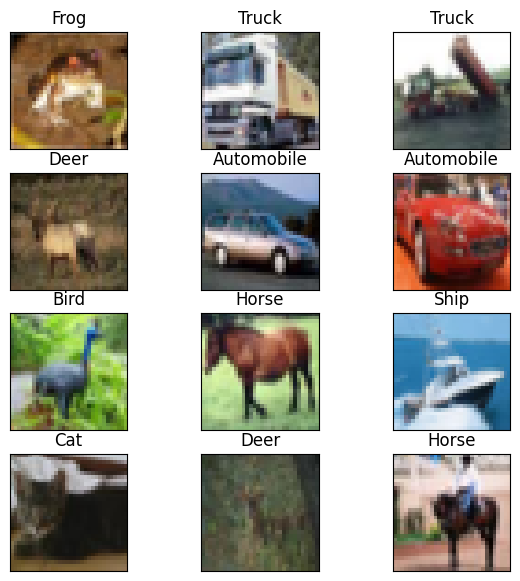

In [10]:
labels = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

fig, axes = plt.subplots(ncols = 3, nrows = 4, figsize = (7, 7))
 
index = 0 
for i in range(4):
  for j in range(3):
    axes[i,j].set_title(labels[y_train[index][0]])
    axes[i,j].imshow(X_train[index])
    axes[i,j].get_xaxis().set_visible(False)
    axes[i,j].get_yaxis().set_visible(False)
    index += 1

In [11]:
# Normalize the images
X_train  = X_train/255.0
X_test  = X_test/255.0

In [12]:
# One hot encoding
from tensorflow.keras.utils import to_categorical
 
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
print(y_train)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(50000, 10))

In [13]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
 
 
model = Sequential()
 
# Convolutional Layer
model.add(Conv2D(filters = 32, 
                 kernel_size = (3,3), 
                 input_shape = (32, 32, 3 ),
                 activation = 'relu',
                 padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
 
# Pooling layer
model.add(MaxPool2D( pool_size = (2,2)))
 
# Dropout Layer
model.add(Dropout(0.25))
 
 
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
 
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
 
 
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
 
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
 
# Flattening 
model.add(Flatten())
 
# Fully connected layers
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.25))
model.add(Dense(10, activation = 'softmax'))

C:\Users\Avinash Navlani\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# compilation
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# model training
model.fit(X_train, y_train, epochs=12)

Epoch 1/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 123s 72ms/step - accuracy: 0.4664 - loss: 1.4938
Epoch 2/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 109s 70ms/step - accuracy: 0.6282 - loss: 1.0574
Epoch 3/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 110s 70ms/step - accuracy: 0.6869 - loss: 0.9005
Epoch 4/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 101s 64ms/step - accuracy: 0.7286 - loss: 0.7932
Epoch 5/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.7554 - loss: 0.7154
Epoch 6/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.7772 - loss: 0.6544
Epoch 7/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.7918 - loss: 0.6087
Epoch 8/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.8069 - loss: 0.5671
Epoch 9/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 101s 65ms/step - accuracy: 0.8218 - loss: 0.5257
Epoch 10/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1669s 1s/step - accuracy: 0.8318 - loss: 0.4950
Epoch 11/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 107s 68ms/step - accuracy: 0.8399 - loss: 0.470

In [17]:
prediction = model.evaluate(X_test, y_test)
print(f'Test Accuracy : {prediction[1] * 100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7863 - loss: 0.6960
Test Accuracy : 78.63%


## RNN

In [28]:
!pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 8.6 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=8b9c34f1ef51a42127fa80687aaf711054497df9a410fb5619e117934512179b
  Stored in directory: c:\users\avinash navlani\appdata\local\pip\cache\wheels\e9\25\85\25d2e1cfc0ece64b930b16972f7e4cc3599c43b531f1eba06d
Successfully built multitasking

   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

import yfinance as yf

In [31]:
# Download NVIDIA stock data
df_nvda = yf.download("NVDA", start="2015-01-01", end="2024-12-31")

# Show first 5 rows
print(df_nvda.head())

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          NVDA      NVDA      NVDA      NVDA       NVDA
Date                                                         
2015-01-02  0.482985  0.486584  0.475307  0.482985  113680000
2015-01-05  0.474828  0.484425  0.472668  0.482985  197952000
2015-01-06  0.460432  0.476027  0.459952  0.475547  197764000
2015-01-07  0.459232  0.467869  0.457792  0.463791  321808000
2015-01-08  0.476507  0.479386  0.464271  0.464511  283780000


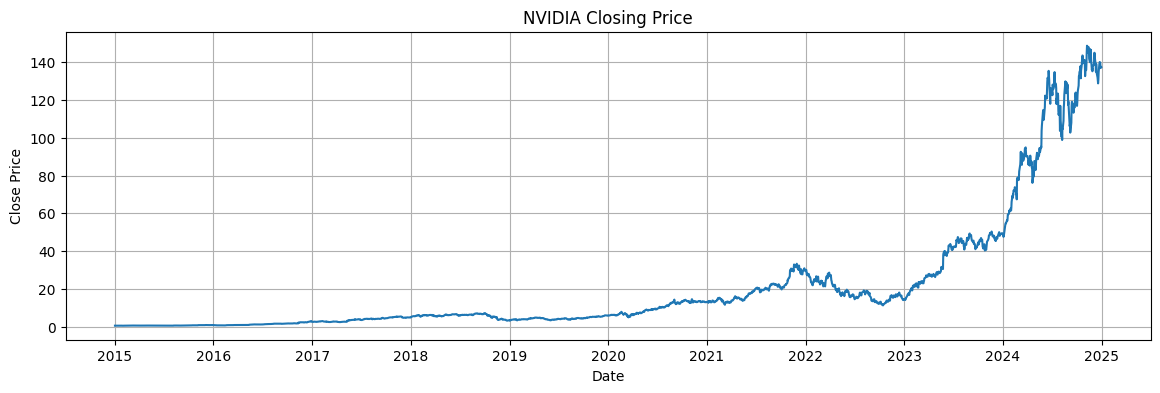

In [32]:
# Select only the Close column
df = df_nvda[['Close']].copy()

# Plot closing price
plt.figure(figsize=(14, 4))
plt.plot(df['Close'])
plt.title("NVIDIA Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

In [34]:
# Use 80% data for training and 20% for testing
split_index = int(len(df) * 0.80)

train_data = df[:split_index].values
test_data = df[split_index:].values

print("Train shape:", train_data.shape)
print("Test shape :", test_data.shape)

Train shape: (2012, 1)
Test shape : (503, 1)


In [35]:
# Scale the dataset
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print(train_scaled[:5])

[[7.23166953e-04]
 [4.74807639e-04]
 [3.65252698e-05]
 [0.00000000e+00]
 [5.25941747e-04]]


In [37]:
time_step = 100

def create_dataset(dataset, time_step=100):
    X, y = [], []
    
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i + time_step, 0])   # previous 100 values
        y.append(dataset[i + time_step, 0])     # next value
    
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_scaled, time_step)
X_test, y_test = create_dataset(test_scaled, time_step)

print("X_train shape before reshape:", X_train.shape)
print("X_test shape before reshape :", X_test.shape)

X_train shape before reshape: (1912, 100)
X_test shape before reshape : (403, 100)


In [38]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape after reshape:", X_train.shape)
print("X_test shape after reshape :", X_test.shape)

X_train shape after reshape: (1912, 100, 1)
X_test shape after reshape : (403, 100, 1)


In [52]:
model = Sequential()

# First RNN layer
model.add(SimpleRNN(50, return_sequences=True, input_shape=(time_step, 1)))

# Second RNN layer
model.add(SimpleRNN(50, return_sequences=True))

# Third RNN layer
model.add(SimpleRNN(50))

# Output layer
model.add(Dense(1))

C:\Users\Avinash Navlani\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [53]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)             │ (None, 100, 50)             │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_4 (SimpleRNN)             │ (None, 100, 50)             │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_5 (SimpleRNN)             │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,751 (49.81 KB)

 Trainable params: 12,751 (49.81 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - loss: 0.0213 - val_loss: 2.9477
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 6.0688e-04 - val_loss: 2.8053
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 5.5913e-04 - val_loss: 2.7096
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 5.5546e-04 - val_loss: 2.6576
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 5.3370e-04 - val_loss: 2.5715
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 4.2139e-04 - val_loss: 2.5112
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 4.5899e-04 - val_loss: 2.4570
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 6.1981e-04 - val_loss: 2.4587
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 5.1086e-04 - val_loss: 2.4584
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 4.9704e-04 - val_loss: 2.4219
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 3.8161e-04 - val_loss: 2.4134
Epoch 12/20
60/60 ━━━━━

In [55]:
test_predict = model.predict(X_test)

# Convert predicted values back to original stock price scale
test_predict = scaler.inverse_transform(test_predict)

# Convert actual y_test also back to original scale
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


In [56]:
rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))
print("RMSE:", rmse)

RMSE: 49.00803932162562


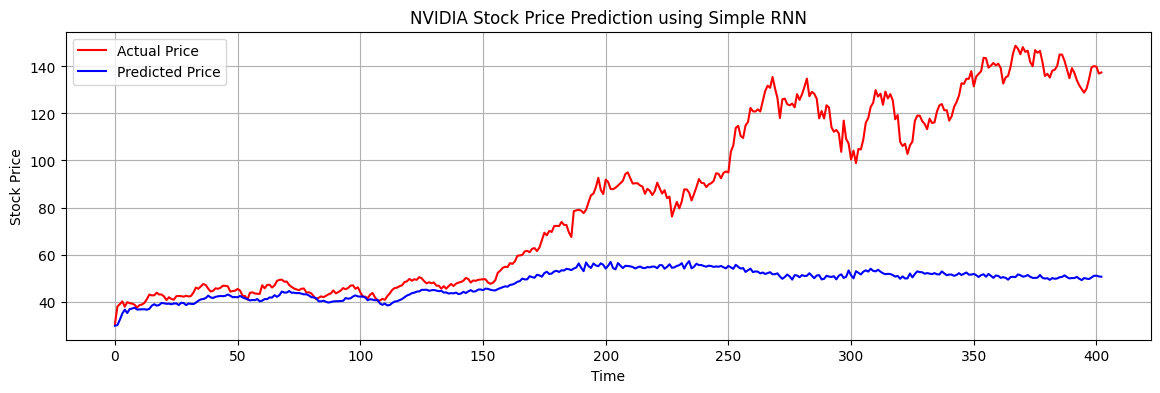

In [57]:
plt.figure(figsize=(14, 4))
plt.plot(y_test_actual, color='red', label='Actual Price')
plt.plot(test_predict, color='blue', label='Predicted Price')
plt.title("NVIDIA Stock Price Prediction using Simple RNN")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

## Long Short Term Memory (LSTM) 

In [46]:
from tensorflow.keras.layers import LSTM

model = Sequential()

# First LSTM layer
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))

# Second LSTM layer
model.add(LSTM(50, return_sequences=True))

# Third LSTM layer
model.add(LSTM(50))

# Output layer
model.add(Dense(1))

C:\Users\Avinash Navlani\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [47]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 50)             │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step - loss: 0.0127 - val_loss: 2.4112
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - loss: 0.0014 - val_loss: 2.1146
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0012 - val_loss: 1.5229
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - loss: 0.0012 - val_loss: 1.5227
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 8.8414e-04 - val_loss: 1.3471
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - loss: 7.9686e-04 - val_loss: 0.8566
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - loss: 6.6111e-04 - val_loss: 0.6024
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 6.7341e-04 - val_loss: 0.6060
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 5.3398e-04 - val_loss: 0.4970
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - loss: 5.0285e-04 - val_loss: 0.3120
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 6.5416e-04 - val_loss: 0.2884
Epoch 12/20
60/60 ━━━━

In [49]:
test_predict = model.predict(X_test)

# Convert predicted values back to original scale
test_predict = scaler.inverse_transform(test_predict)

# Convert actual test values back to original scale
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step


In [50]:
rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))
print("RMSE:", rmse)

RMSE: 15.716354097792163


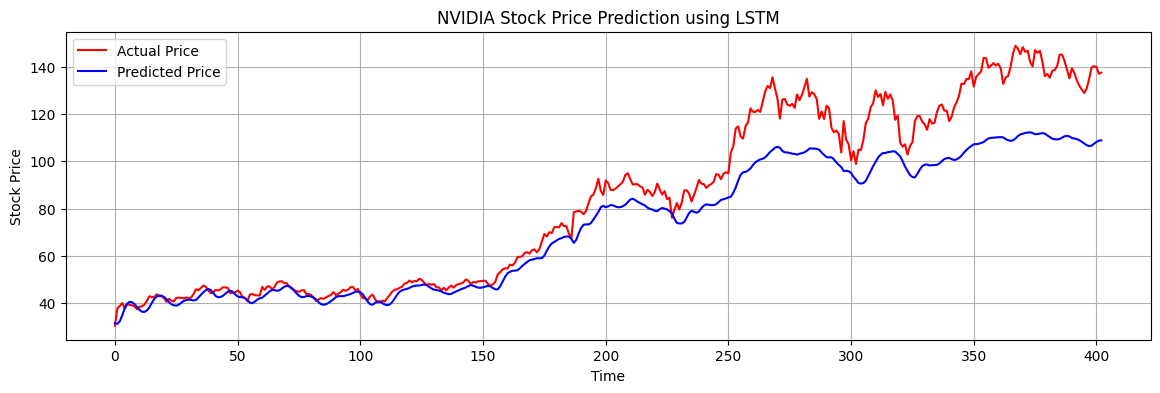

In [51]:
plt.figure(figsize=(14, 4))
plt.plot(y_test_actual, color='red', label='Actual Price')
plt.plot(test_predict, color='blue', label='Predicted Price')
plt.title("NVIDIA Stock Price Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

## Autoencoders 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

In [3]:
# Load CIFAR-10 data
(x_train, _), (x_test, _) = cifar10.load_data()

print("Training shape:", x_train.shape)
print("Testing shape :", x_test.shape)

Training shape: (50000, 32, 32, 3)
Testing shape : (10000, 32, 32, 3)


In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Min pixel value:", x_train.min())
print("Max pixel value:", x_train.max())

Min pixel value: 0.0
Max pixel value: 1.0


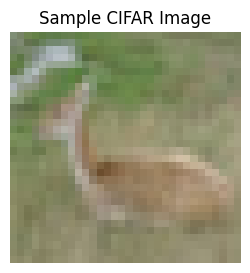

In [5]:
plt.figure(figsize=(3, 3))
plt.imshow(x_train[130])
plt.title("Sample CIFAR Image")
plt.axis("off")
plt.show()

In [6]:
# Input image size: 32x32x3
input_img = Input(shape=(32, 32, 3))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Autoencoder model
autoencoder = Model(input_img, decoded)

In [7]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 16)            │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 3)           │             867 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,347 (52.14 KB)

 Trainable params: 13,347 (52.14 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - loss: 0.5821 - val_loss: 0.5679
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - loss: 0.5647 - val_loss: 0.5637
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - loss: 0.5621 - val_loss: 0.5622
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 49s 124ms/step - loss: 0.5610 - val_loss: 0.5615
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - loss: 0.5604 - val_loss: 0.5608
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - loss: 0.5598 - val_loss: 0.5602
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - loss: 0.5594 - val_loss: 0.5599
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - loss: 0.5591 - val_loss: 0.5596
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - loss: 0.5588 - val_loss: 0.5594
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - loss: 0.5585 - val_loss: 0.5591


In [9]:
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


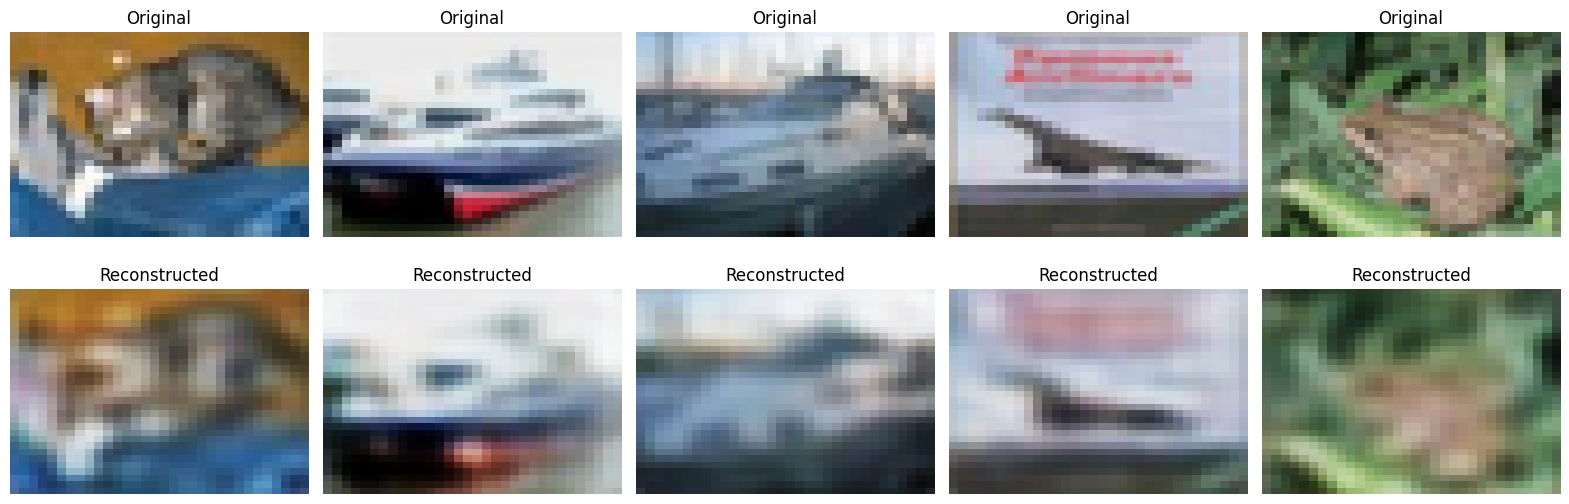

In [12]:
n = 5  # number of images to display

plt.figure(figsize=(4*n, 6))

for i in range(n):
    # Original image
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], aspect='auto')
    plt.title("Original")
    plt.axis("off")

    # Reconstructed image
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i], aspect='auto')
    plt.title("Reconstructed")
    plt.axis("off")

plt.subplots_adjust(wspace=0.05, hspace=0.25)
plt.show()

## Denoising Autoencoder

In [22]:
noise_factor = 0.2

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

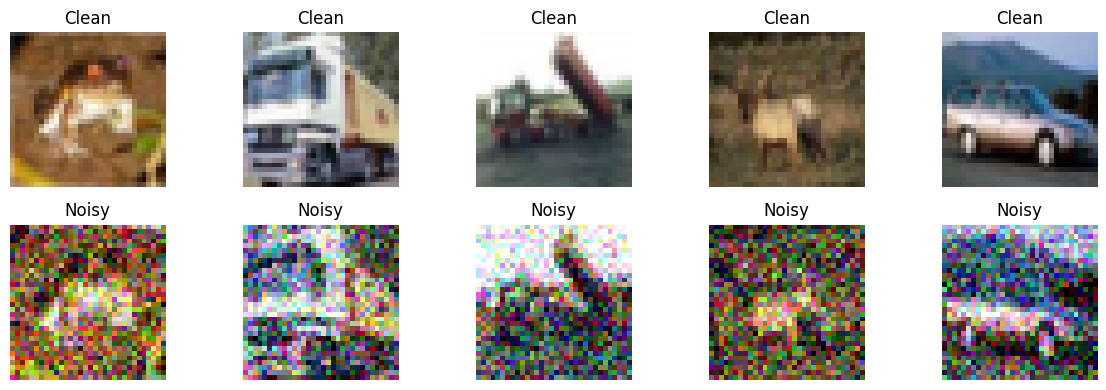

In [23]:
n = 5
plt.figure(figsize=(12, 4))

for i in range(n):
    # clean image
    plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i])
    plt.title("Clean")
    plt.axis("off")

    # noisy image
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i])
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 16)            │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 3)           │             867 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,347 (52.14 KB)

 Trainable params: 13,347 (52.14 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - loss: 0.5684 - val_loss: 0.5664
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - loss: 0.5652 - val_loss: 0.5658
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 0.5647 - val_loss: 0.5656
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - loss: 0.5644 - val_loss: 0.5650
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - loss: 0.5641 - val_loss: 0.5650
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - loss: 0.5640 - val_loss: 0.5646
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - loss: 0.5637 - val_loss: 0.5645
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - loss: 0.5636 - val_loss: 0.5642
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - loss: 0.5635 - val_loss: 0.5642
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 0.5633 - val_loss: 0.5640


In [27]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


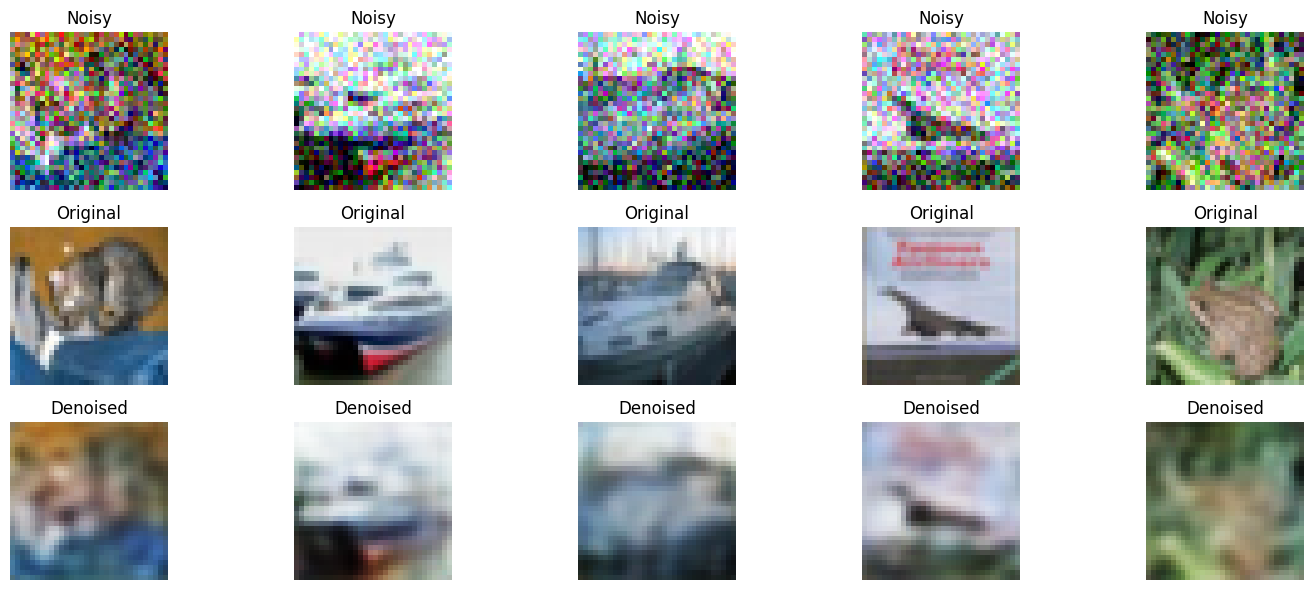

In [28]:
n = 5
plt.figure(figsize=(15, 6))

for i in range(n):
    # noisy input
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    plt.axis("off")

    # original clean image
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")

    # denoised output
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i])
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()